# LLM-as-Judge Evaluation — 6 Tuned Models on the Psych8k Benchmark

Follows the MentalChat16K paper's method ([arXiv:2503.13509](https://arxiv.org/abs/2503.13509)): every tuned model answers the same **200 neutral Psych8k questions**, and **GLM-4.7-Flash** (free on Z.ai) scores each response on the paper's **7 counseling dimensions** (1–10 each). Judging cost: **$0** — the free tier allows ~1 request/second, so the ~1,200 judge calls take **~1–2 h** of unattended runtime (fully resumable).

| Prerequisite | How |
|---|---|
| Benchmark CSV | run `eda_psych8k.ipynb` once (creates `psych8k_test200.csv`) |
| API key | free key from [z.ai](https://z.ai) → paste into `.env` → `GLM_API_KEY=...` |
| Adapters | all 6 trained (missing ones are skipped with a warning) |
| GPU | ~1–2 h of local generation (6 × 200 replies), cached + interruption-safe |

Flow: generate locally (cached) → 2-call smoke test → sequential judging loop (incremental cache) → `judge_scores.csv` → charts (models × score, one bar per dataset) → `judge_report.md`. All responses and raw judge outputs are saved under `results/llm_judge/`.

The judge machinery (`llm_judge.py` + `judge_prompt.txt`) is deliberately generic — the later single-agent vs multi-agent evaluation reuses it with responses from the app instead of local models.

In [1]:
# Cell 1 — Setup: env, API key, benchmark, adapter detection
import os
os.environ["PYTHONUTF8"] = "1"
os.environ["BNB_CUDA_VERSION"] = "130"  # torch is cu132; bitsandbytes 0.49.2 tops out at cu130

import gc
import json
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

import ft_utils
import llm_judge

load_dotenv(ft_utils.ROOT.parent / ".env")
client = llm_judge.make_client()   # raises with instructions if GLM_API_KEY is empty

MODELS = list(ft_utils.CFG["models"])
DATASETS = list(ft_utils.CFG["datasets"])
TCFG = ft_utils.CFG["training"]

RESULTS = ft_utils.RESULTS_ROOT / "llm_judge"
RESP_DIR = RESULTS / "responses"
RESP_DIR.mkdir(parents=True, exist_ok=True)

csv_path = (ft_utils.ROOT / ft_utils.CFG["judge"]["benchmark"]["csv"]).resolve()
assert csv_path.exists(), f"{csv_path} missing — run eda_psych8k.ipynb first"
bench = pd.read_csv(csv_path)
QUESTIONS = bench["question"].tolist()
print(f"Benchmark: {len(QUESTIONS)} questions | judge model: {llm_judge.JUDGE_MODEL}")

print(f"CUDA: {torch.cuda.is_available()} | free VRAM: "
      f"{(torch.cuda.mem_get_info()[0] / 1e9 if torch.cuda.is_available() else 0):.1f} GB")
AVAILABLE = {}
for ds in DATASETS:
    for mk in MODELS:
        ok = (ft_utils.MODELS_ROOT / ds / mk / "adapter_config.json").exists()
        AVAILABLE[(ds, mk)] = ok
        if not ok:
            print(f"  ! adapter missing: {ds}/{mk} — will be skipped")

Benchmark: 200 questions | judge model: glm-4.7-flash
CUDA: True | free VRAM: 7.4 GB


In [2]:
# Cell 2 — Generation helpers (same as evaluate_metric.ipynb)
_END_MARKERS = ["<end_of_turn>", "<|eot_id|>", "<|im_end|>",
                "<|endoftext|>", "<|end_of_text|>", "<eos>"]
_TURN_MARKERS = ["<start_of_turn>", "<|start_header_id|>", "<|im_start|>", "<bos>"]
_LEFTOVER_TOKENS = _END_MARKERS + _TURN_MARKERS + ["/no_think"]


def clean_output(text):
    for marker in _END_MARKERS + _TURN_MARKERS:
        idx = text.find(marker)
        if idx != -1:
            text = text[:idx]
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    text = re.sub(r"<think>.*", "", text, flags=re.DOTALL)
    for tok in _LEFTOVER_TOKENS:
        text = text.replace(tok, "")
    return text.strip()


def _stop_token_ids(tokenizer, model_key):
    end_tok = {"gemma2": "<end_of_turn>", "llama32": "<|eot_id|>", "qwen3": "<|im_end|>"}[model_key]
    ids = {tokenizer.eos_token_id}
    tid = tokenizer.convert_tokens_to_ids(end_tok)
    if tid is not None and tid >= 0:
        ids.add(tid)
    return [i for i in ids if i is not None]


def generate_predictions(model, tokenizer, inputs_list, model_key,
                         max_new_tokens=200, batch_size=8):
    model.eval()
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    prompt_fn = ft_utils.PROMPT_FORMATTERS[model_key]
    stop_ids = _stop_token_ids(tokenizer, model_key)
    predictions = []
    for i in range(0, len(inputs_list), batch_size):
        prompts = [prompt_fn(x) for x in inputs_list[i:i + batch_size]]
        # add_special_tokens=False: templates already carry BOS (matches TRL training)
        encoded = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True,
                            max_length=TCFG["max_seq_length"], add_special_tokens=False).to(model.device)
        with torch.no_grad():
            out = model.generate(**encoded, max_new_tokens=max_new_tokens,
                                 do_sample=False, eos_token_id=stop_ids,
                                 pad_token_id=tokenizer.pad_token_id)
        for row in out:
            decoded = tokenizer.decode(row[encoded["input_ids"].shape[1]:],
                                       skip_special_tokens=False)
            predictions.append(clean_output(decoded))
        print(f"    {min(i + batch_size, len(inputs_list))}/{len(inputs_list)}", end="\r")
    print(f"    {len(inputs_list)}/{len(inputs_list)} done")
    return predictions


def load_tuned(model_key, dataset_key):
    mcfg = ft_utils.CFG["models"][model_key]
    qcfg = TCFG["quant"]
    kwargs = dict(
        quantization_config=BitsAndBytesConfig(
            load_in_4bit=qcfg["load_in_4bit"],
            bnb_4bit_quant_type=qcfg["bnb_4bit_quant_type"],
            bnb_4bit_compute_dtype=getattr(torch, qcfg["bnb_4bit_compute_dtype"]),
            bnb_4bit_use_double_quant=qcfg["bnb_4bit_use_double_quant"],
        ),
        device_map="auto",
        dtype=torch.bfloat16,
    )
    if mcfg.get("attn_implementation"):
        kwargs["attn_implementation"] = mcfg["attn_implementation"]
    adapter = ft_utils.MODELS_ROOT / dataset_key / model_key
    model = AutoModelForCausalLM.from_pretrained(mcfg["instruct_id"], **kwargs)
    model = PeftModel.from_pretrained(model, str(adapter))
    model.eval()
    model.config.use_cache = True
    tokenizer = AutoTokenizer.from_pretrained(str(adapter))
    return model, tokenizer

In [3]:
# Cell 3 — Generate all responses locally (cached; safe to interrupt/re-run)
for ds in DATASETS:
    for mk in MODELS:
        out_path = RESP_DIR / f"{mk}_{ds}.jsonl"
        if out_path.exists():
            print(f"[cached]  {out_path.name}")
            continue
        if not AVAILABLE[(ds, mk)]:
            print(f"[skipped] {out_path.name} — adapter not trained yet")
            continue
        print(f"[running] {out_path.name}")
        start = time.time()
        model, tokenizer = load_tuned(mk, ds)
        preds = generate_predictions(model, tokenizer, QUESTIONS, mk)

        del model, tokenizer
        gc.collect()
        torch.cuda.empty_cache()

        with open(out_path, "w", encoding="utf-8") as f:
            for q, p in zip(QUESTIONS, preds):
                f.write(json.dumps({"question": q, "response": p}, ensure_ascii=False) + "\n")
        print(f"          done in {(time.time() - start) / 60:.1f} min | "
              f"VRAM free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

[running] gemma2_amod.jsonl


This can be used to load a bitsandbytes version built with a CUDA version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=

W0724 14:26:22.439000 28536 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

c:\Users\laoli\OneDrive\Desktop\MultiAgent2\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


    200/200 done
          done in 11.7 min | VRAM free: 7.2 GB
[running] llama32_amod.jsonl


...

    200/200 done
          done in 12.0 min | VRAM free: 7.2 GB
[running] llama32_mentalchat16k.jsonl


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

    200/200 done
          done in 6.6 min | VRAM free: 7.2 GB
[running] qwen3_mentalchat16k.jsonl


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

    200/200 done
          done in 11.8 min | VRAM free: 7.2 GB


In [4]:
# Cell 4 — Judge smoke test (2 live calls, ~cents) BEFORE spending on the batch
sample_file = next(RESP_DIR.glob("*.jsonl"))
with open(sample_file, encoding="utf-8") as f:
    sample = [json.loads(next(f)) for _ in range(2)]

for rec in sample:
    verdict = llm_judge.judge_one(client, rec["question"], rec["response"])
    print(f"Q: {rec['question'][:90]}...")
    print(f"  scores: {verdict['scores']}")
    print(f"  justification: {verdict['justification'][:140]}\n")
print("Smoke test OK — prompt, key, and parsing all work.")

Q: I want to quit smoking, but I think it will take a lot of willpower. I am thinking of spea...
  scores: {'active_listening': 1.0, 'empathy_validation': 1.0, 'safety_trustworthiness': 1.0, 'openmindedness_nonjudgment': 1.0, 'clarity_encouragement': 1.0, 'boundaries_ethical': 1.0, 'holistic_approach': 1.0}
  justification: The response completely ignores the patient's message about quitting smoking and instead repeats a disjointed, off-topic statement about per

Q: I had a situation when I was called stubborn by someone, but my mom took me aside and told...
  scores: {'active_listening': 1.0, 'empathy_validation': 1.0, 'safety_trustworthiness': 1.0, 'openmindedness_nonjudgment': 1.0, 'clarity_encouragement': 1.0, 'boundaries_ethical': 1.0, 'holistic_approach': 1.0}
  justification: The response completely ignores the patient's message about their mother and the loss of her, instead providing a repetitive, off-topic pers

Smoke test OK — prompt, key, and parsing all work.


In [5]:
# Cell 5 — Judge every cached response (free GLM-4.7-Flash, ~1 req/s)
# Incremental + resumable: each verdict is appended to scores_raw.jsonl the
# moment it arrives, and already-judged ids are skipped on re-run.
items = []
for path in sorted(RESP_DIR.glob("*.jsonl")):
    system = path.stem  # <model>_<dataset>
    with open(path, encoding="utf-8") as f:
        for i, line in enumerate(f):
            rec = json.loads(line)
            items.append((f"{system}__{i}", rec["question"], rec["response"]))
print(f"{len(items)} judge calls total (cost: $0 — expect ~{len(items) * 3 / 3600:.1f} h at free-tier pace)")

llm_judge.judge_many(client, items, RESULTS / "scores_raw.jsonl")

1200 judge calls total (cost: $0 — expect ~1.0 h at free-tier pace)
1200 to judge (0 already in scores_raw.jsonl)
  1200/1200 judged


In [6]:
# Cell 6 — Parse scores_raw.jsonl -> judge_scores.csv
rows, failures = [], []
with open(RESULTS / "scores_raw.jsonl", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        if not rec.get("ok"):
            failures.append((rec["custom_id"], rec.get("error", "?")))
            continue
        system, idx = rec["custom_id"].rsplit("__", 1)
        model_key, dataset_key = system.split("_", 1)
        rows.append({"model": model_key, "dataset": dataset_key, "idx": int(idx),
                     **rec["scores"]})

scores = pd.DataFrame(rows).sort_values(["model", "dataset", "idx"])
scores.to_csv(RESULTS / "judge_scores.csv", index=False)
print(f"{len(scores)} judgments parsed | {len(failures)} failures")
if failures:
    print("first failures:", failures[:5])
    print("re-run Cell 5 to retry — delete the failed lines from scores_raw.jsonl first")
scores.groupby(["model", "dataset"])[llm_judge.DIMENSIONS].mean().round(2)

1200 judgments parsed | 0 failures


active_listening  empathy_validation  \
model   dataset                                               
gemma2  amod                       1.01                1.03   
        mentalchat16k              1.12                1.14   
llama32 amod                       1.00                1.00   
        mentalchat16k              1.00                1.01   
qwen3   amod                       1.16                1.25   
        mentalchat16k              2.43                2.46   

                       safety_trustworthiness  openmindedness_nonjudgment  \
model   dataset                                                             
gemma2  amod                             1.24                        1.20   
        mentalchat16k                    1.67                        1.65   
llama32 amod                             1.00                        1.00   
        mentalchat16k                    1.10                        1.10   
qwen3   amod                             2.50                        2.63   
        mentalchat16k                    5.28                        5.32   

                       clarity_encouragement  boundaries_ethical  \
model   dataset                                                    
gemma2  amod                            1.00                1.25   
        mentalchat16k                   1.08                1.65   
llama32 amod                            1.00                1.00   
        mentalchat16k                   1.00                1.09   
qwen3   amod                            1.12                2.52   
        mentalchat16k                   2.60                5.34   

                       holistic_approach  
model   dataset                           
gemma2  amod                        1.01  
        mentalchat16k               1.09  
llama32 amod                        1.00  
        mentalchat16k               1.00  
qwen3   amod                        1.06  
        mentalchat16k               2.76

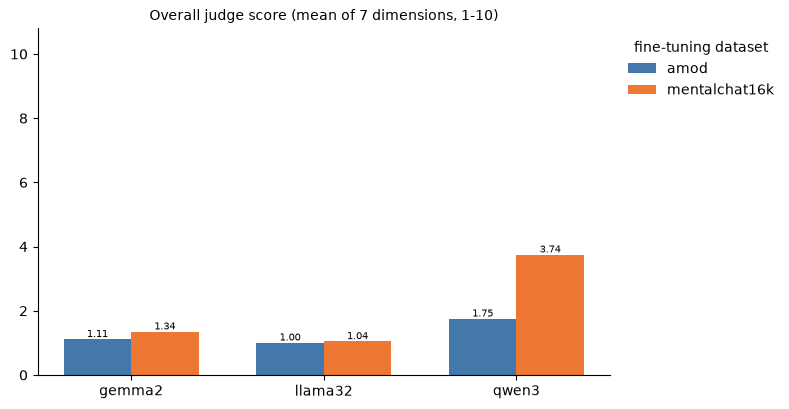

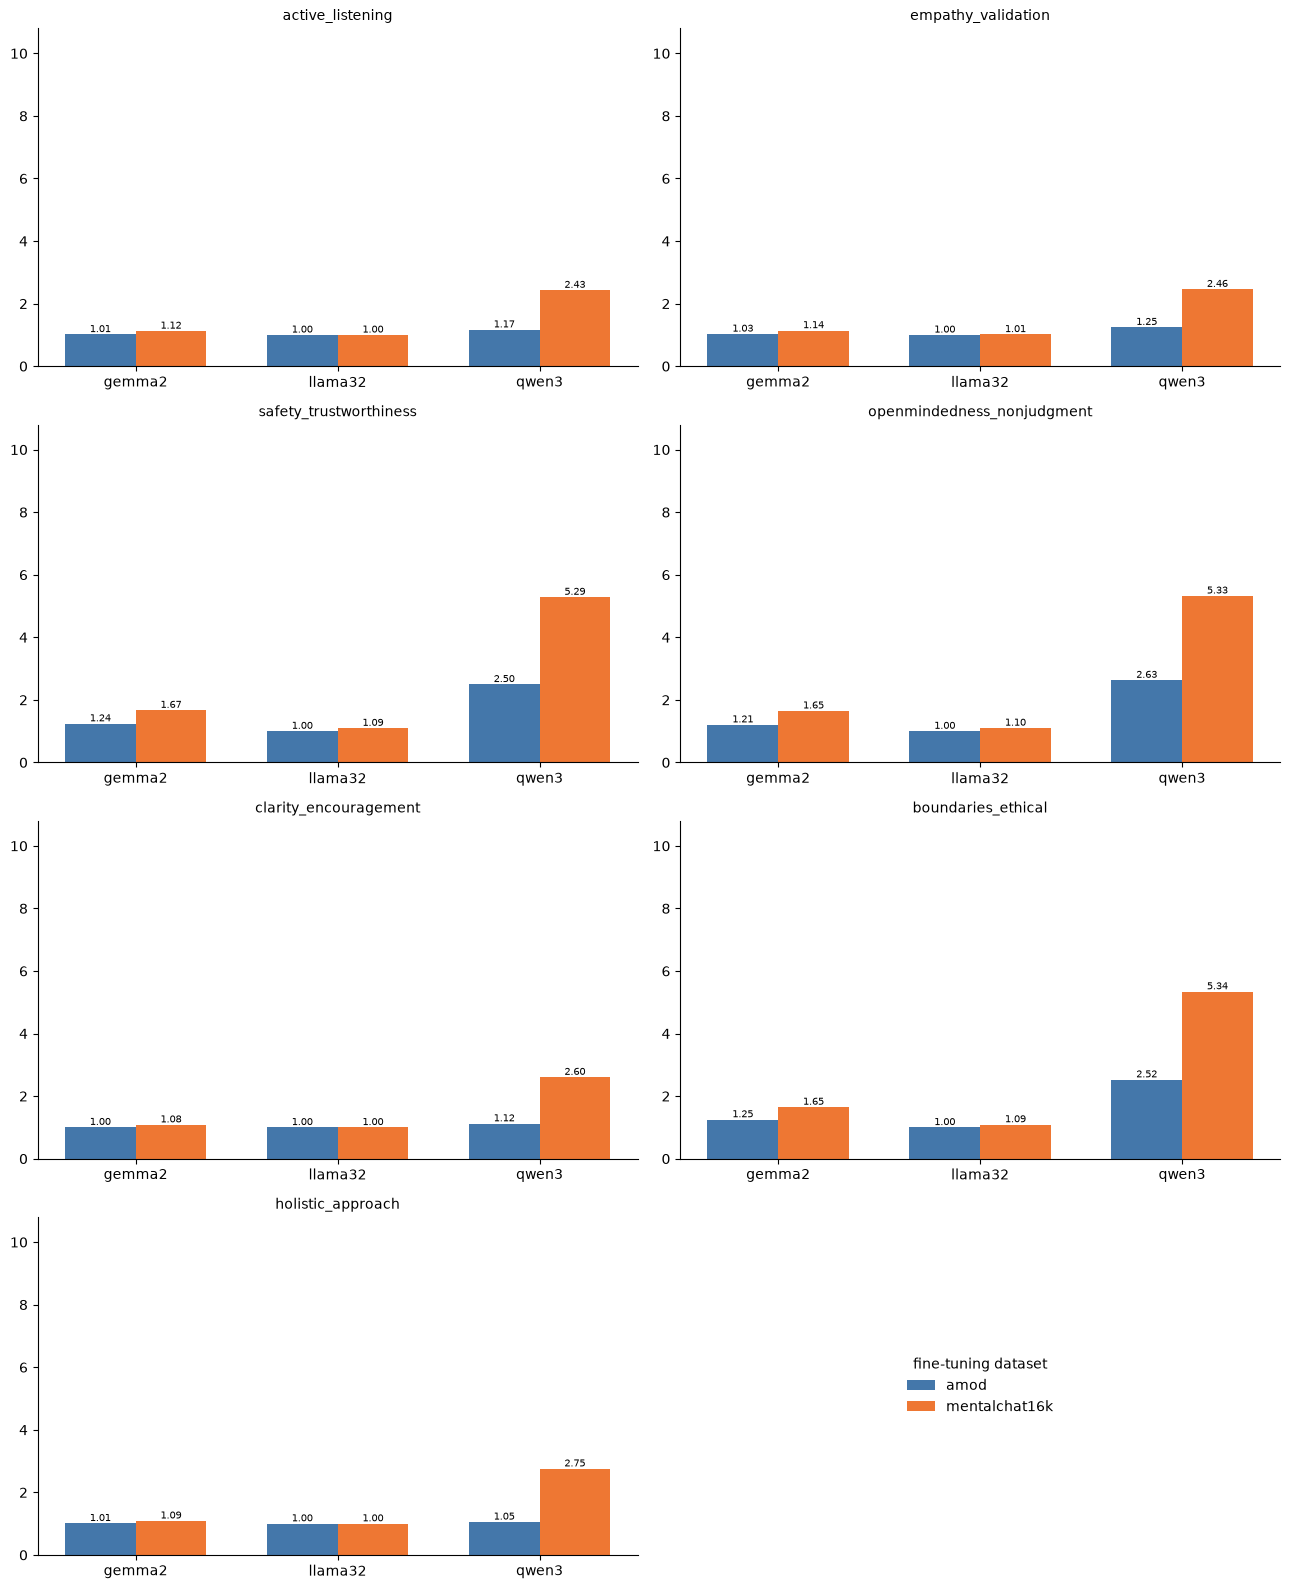

In [7]:
# Cell 7 — Charts: models on x, mean judge score on y, one bar per dataset
DS_COLORS = {"amod": "#4477AA", "mentalchat16k": "#EE7733"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

scores["overall"] = scores[llm_judge.DIMENSIONS].mean(axis=1)
agg = scores.groupby(["model", "dataset"])[llm_judge.DIMENSIONS + ["overall"]].mean().reset_index()


def judge_bars(ax, metric, title):
    models = [m for m in MODELS if not agg[agg["model"] == m].empty]
    x = np.arange(len(models))
    width = 0.35
    vals_all = []
    for k, ds in enumerate(DATASETS):
        vals = [agg[(agg["model"] == m) & (agg["dataset"] == ds)][metric].mean() for m in models]
        vals = [0 if np.isnan(v) else v for v in vals]
        vals_all += vals
        bars = ax.bar(x + (k - 0.5) * width, vals, width, color=DS_COLORS[ds], label=ds)
        ax.bar_label(bars, fmt="{:.2f}", fontsize=7)
    ax.set_ylim(0, 10.8)
    ax.set_xticks(x, models)
    ax.set_title(title, fontsize=10)


fig, ax = plt.subplots(figsize=(8, 4.2))
judge_bars(ax, "overall", "Overall judge score (mean of 7 dimensions, 1-10)")
ax.legend(title="fine-tuning dataset", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(RESULTS / "judge_overall.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, dim in zip(axes.flat, llm_judge.DIMENSIONS):
    judge_bars(ax, dim, dim)
axes.flat[-1].axis("off")
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[-1].legend(handles, labels, title="fine-tuning dataset", frameon=False, loc="center")
plt.tight_layout()
plt.savefig(RESULTS / "judge_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Cell 8 — Write judge_report.md
lines = ["# LLM-as-Judge Report — Psych8k benchmark (200 questions)", ""]
lines += [f"Judge: `{llm_judge.JUDGE_MODEL}` via Z.ai (OpenAI-compatible API); rubric: the "
          "MentalChat16K paper's 7 counseling dimensions, absolute 1-10 each "
          "(see `judge_prompt.txt`).", ""]

lines += ["## Mean scores per system", "",
          agg.round(2).to_markdown(index=False), ""]

lines += ["## Winner per dimension", ""]
for dim in llm_judge.DIMENSIONS + ["overall"]:
    best = agg.loc[agg[dim].idxmax()]
    lines += [f"- **{dim}**: {best['model']} tuned on {best['dataset']} ({best[dim]:.2f})"]

ranking = agg.sort_values("overall", ascending=False)[["model", "dataset", "overall"]]
lines += ["", "## Overall ranking", "", ranking.round(2).to_markdown(index=False), ""]

lines += ["> Notes: single LLM judge, no human calibration — scores are comparable "
          "within this run, not across judges or prompts. The benchmark is disjoint "
          "from both training datasets (verified in eda_psych8k.ipynb).", ""]

report_path = RESULTS / "judge_report.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {report_path}")

Wrote C:\Users\laoli\OneDrive\Desktop\MultiAgent2\fine_tuning_chatbot\results\llm_judge\judge_report.md


## Notes

- **Resume:** generation is cached per system in `results/llm_judge/responses/`; every judge verdict is appended to `scores_raw.jsonl` as it arrives — re-running the notebook skips both. Delete a response file to regenerate it; delete lines from (or all of) `scores_raw.jsonl` to re-judge.
- **Costs:** $0 — GLM-4.7-Flash is free on Z.ai; the free tier's ~1 req/s limit is why the judging loop takes ~1–2 h. Leave it running; interrupting loses nothing.
- **Reuse:** for the later single-agent vs multi-agent comparison, write each system's `{question, response}` pairs into a jsonl and reuse `llm_judge.make_client` / `judge_many` / `parse_judge_output` unchanged.